# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 2</span>

### Exercise 02.1
- Compute the following 1D integral via Monte Carlo 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$

1. sampling a uniform distribution in $[0,1]$<br/>
2. using importance sampling (i.e. sampling a non-uniform probability in $[0,1]$)

<font color="red">Show a picture of both your estimations of $I$</font> and their uncertainties with a large number of *throws* $M$ (e.g. $M\ge 10^4$) as a function of the number of blocks, $N$.

## Monte Carlo integration

### 1) Using a uniform distribution

The computation takes advantage of the following result. Let us consider the integral on the interval $[a,b]$:

$$ I=\int_{a}^{b} f(x) dx = \lim_{N \to +\infty} \sum_{i=1}^{N} \Delta x f(x_i) $$

Which after making the substitution $\Delta x = \frac{(b-a)}{N}$ can be written as:

$$
\begin{align*}
I &= \lim_{N \to +\infty} \sum_{i=1}^{N} \Delta x f(x_i) = \frac{(b-a)}{N} \lim_{N \to +\infty}  \sum_{i=1}^{N} f(x_i) \\
I &= (b-a) \lim_{N \to +\infty}  \frac{1}{N}\sum_{i=1}^{N} f(x_i) \\
I &= (b-a)\langle f \rangle_{[a,b]} \\
\end{align*}
$$

An <b>estimation</b> of $\langle f \rangle$ can be computed using random variables $x_i$ uniformly distributed on [a,b] as:

$$ I=(b-a)\langle f \rangle _{[a,b]} \cong (b-a) \frac{1}{N} \sum_{i=1}^{N} f(x_i)$$

For this particular integral we get:

$$ I = (1-0)\langle f \rangle _{[0,1]} \cong \frac{1}{N} \sum_{i=1}^{N} \frac{\pi}{2} cos(\pi x /2) $$

where $N=10^4$

### 2) Using importance sampling

Suppose we wish to evaluate the n-dimensional Monte Carlo integral:

$$ I = \int g(\vec{x}) p(\vec{x}) d \vec{x} $$

The idea behind <em>importance sampling</em> is to find a probability distribution function $p(\vec{x})$ that better suits the indicator function $g(\vec{x})$ (instead of the classical uniform probability distribution). The aim is to reduce the variance of $g(\vec{x})$.

To find this new probability distribution, let's use the following trick. We multiply $p(\vec{x})$ by $\frac{q(\vec{x})}{q(\vec{x})}$. Then we get:

$$  I = \int \left[ \frac{g(\vec{x}) p(\vec{x})}{q(\vec{x})} \right] q(\vec{x}) d \vec{x} $$

The expression between bracket is the new probability distribution.

In our case, let's consider the probability distribution $q(x) = 2-2x$, for which the graph between 0 and 1 is close to the original integrand $\frac{\pi}{2}\cos(\pi x/2)$.

We can sample from $q(x)$ by using the inverse transform sampling method.

The cumulative distribution function (CDF) of q(x) is:

$$ Q(x) = \int_{0}^{x} (2-2t) dt = 2x-x^2 $$

To then use the inverse transform sampling, we solve for $x$ in terms of $u$, where $u$ is a uniform random variable in $[0,1]$:

$$ u = Q(x) = 2x-x^2 $$

then,

$$ x= 1-\sqrt{1-u} $$

I added the class "ImportanceSampling" in the random.cpp to sample random values $x$ according to the expression above. 

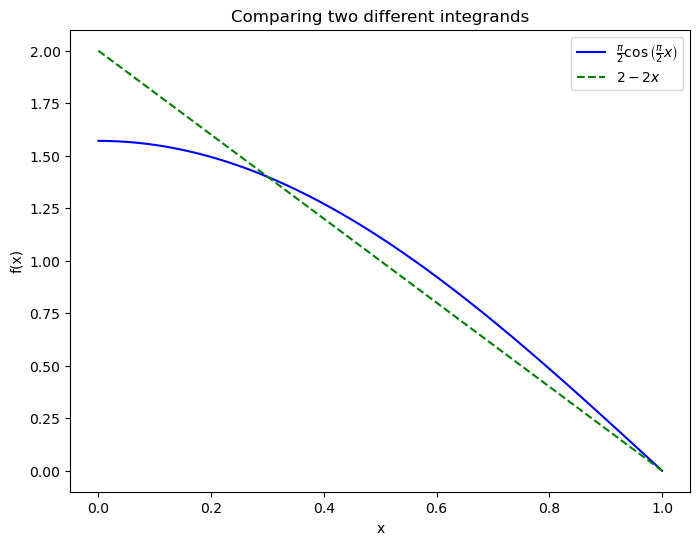

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# Original Integrand
def f(x):
    return np.pi / 2 * np.cos(np.pi / 2 * x)

# New Integrand
def linear_function(x):
    return 2-2*x

# Generate x values
x = np.linspace(0, 1, 400)  # 400 points from 0 to 1

# Compute y values
y = f(x)
y_linear_function = linear_function(x)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=r'$\frac{\pi}{2} \cos\left(\frac{\pi}{2} x\right)$', color='blue')
plt.plot(x, y_linear_function, label='$2-2x$', color='green', linestyle='--')

# Add titles and labels
plt.title('Comparing two different integrands')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

plt.show()

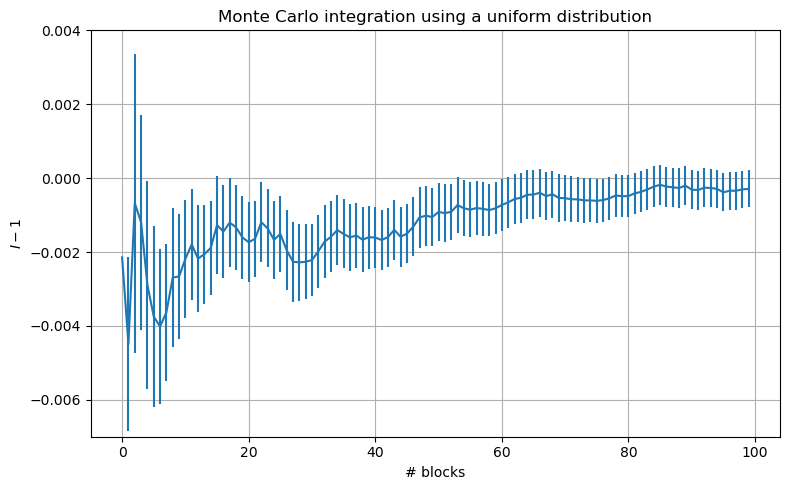

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

file = open("./EX2_Parallel_Random_Generator/output_files/ex2_1_monte_carlo_output.dat")

Lines = file.readlines()

N = len(Lines) # Number of blocks

# Loading data computed in PRG, unsing cols 0 and 1 which respectively correspond to the cumulative sum of the averages
# and its uncertainty

MC_integral, error = np.loadtxt("./EX2_Parallel_Random_Generator/output_files/ex2_1_monte_carlo_output.dat",
                                usecols=(0,2), delimiter= " ", unpack="true", skiprows=1)

x = np.arange(len(MC_integral))

plt.figure(figsize=(8, 5))
plt.grid(True)
plt.errorbar(x, MC_integral-1, yerr=error)
plt.ylim(-0.007, 0.004)
plt.xlabel("# blocks")
plt.ylabel("$I- 1 $")
plt.title("Monte Carlo integration using a uniform distribution")
plt.tight_layout()
plt.show()

plt.show()

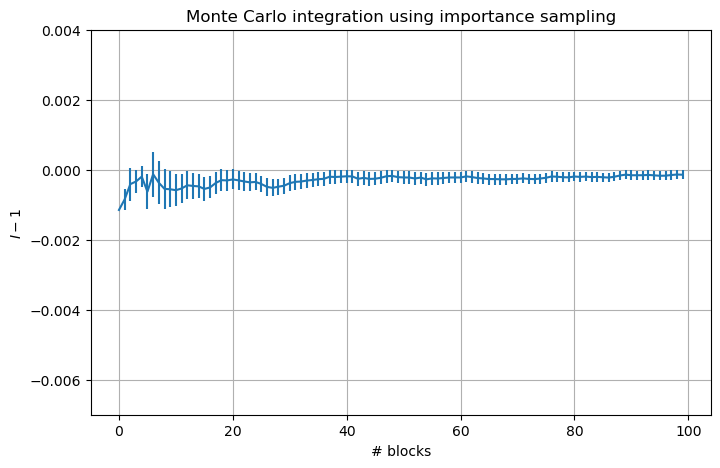

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

file = open("./EX2_Parallel_Random_Generator/output_files/ex2_2_monte_carlo_output_importance_sampling.dat")

Lines = file.readlines()

N = len(Lines) # Number of blocks


# Loading data computed in PRG, unsing cols 0 and 1 which respectively correspond to the cumulative sum of the averages
# and its uncertainty

MC_integral, error = np.loadtxt("./EX2_Parallel_Random_Generator/output_files/ex2_2_monte_carlo_output_importance_sampling.dat",
                                usecols=(0,2), delimiter= " ", unpack="true", skiprows=1)

x = np.arange(len(MC_integral))

plt.figure(figsize=(8, 5))
plt.grid(True)
plt.errorbar(x, MC_integral-1, yerr=error)

plt.ylim(-0.007, 0.004)

plt.xlabel("# blocks")
plt.ylabel("$I- 1 $ ")
plt.title("Monte Carlo integration using importance sampling")

plt.show()

As we can see, the MC integral value $I$ converges faster to 1 and the variance is greatly reduced (note that the y-axis scale is preserved between the two graphs).

### Exercise 02.2
- <font color="red">3D Random Walks (RW) on a cubic lattice and in the continuum:</font> Repeat many times (e.g. say $10^4$) the simulation of a random walk in 3D always starting at the origin.

    1. on a cubic lattice with lattice constant $a=1$; at each discrete time the walker makes a forward or backward step of length equal to $a$ in one of the 3 principal directions of the lattice: $x$, $y$ or $z$.<br/> 

    2. in the continuum; at each discrete time the walker makes a step of length equal to $a(=1)$ along a **random direction** obtained by sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$

- <font color="red">Show a picture of $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ for both RWs</font>, with their statistical uncertainties, as function of the step $i\in [0,10^2]$.

Note that you could try to fit both results with a function like $f(N)=k\sqrt{N}$. Do your results indicate a diffusive behavior?

## Stochastic Processes

<u>Definition</u>: a stochastic process is a family $(x_t)_{t \in I}$ of random variables, where $I$ can either be $\mathbb{R}$ (continuous time) or $\mathbb{N}$ (discrete time). 

# 1) Random Walk on a Cubic Lattice #
---------

This experiment simulates a walker taking random discrete steps on a cubic lattice. To simulate a single step, we generate a random integer between 1 and 6, representing a step taken in any spatial direction $(x,y,z)$, either forward or backwards.

We will compute the average distance $\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$ covered by the random walker as a function of steps $N$(between 0 and 100).

A "single random walk" $r_N$ is a series of $N$ random steps. We will use the blocking method to compute the error on the distance traveled. In order to avoid any confusions with the "squared-squares" in the computation of the variance, let's first rename our variable $|\vec{r}_N|^2 = A$. We get:

$$
\text{error}(\langle A \rangle) = \frac{\sigma}{\sqrt{N}} =\frac{\sqrt{\langle A^2 \rangle - \langle A \rangle^2}}{\sqrt{N}}
$$

Once we fix the number of steps $N$, we make $10^4$ random walks and divide these 100 blocks to compute the relevant values on each block. Essentially:

- **First Block**: Random Walks 1 - 100
   - Compute the average distances traveled of this block $\langle A \rangle _1$
- **Second Block**: Random Walks 101 - 200
   - Compute the average distances traveled of this block $\langle A \rangle _2$
- **...**
  - ...
- **Hundredth Block**: Random Walks 9901 - 10000
   - Compute the average distances traveled  of this block$\langle A \rangle _{100}$

Then:

$$
\langle A(N) \rangle = \frac{1}{B} \sum_{i=1}^{B} \langle A \rangle _i
$$

where $B$ is the number of blocks. So that the **global error** on the distance is given by:

$$
\text{error}(\langle A(N) \rangle) =\frac{\sqrt{\langle A(N)^2 \rangle - \langle A(N) \rangle^2}}{\sqrt{B}}
$$

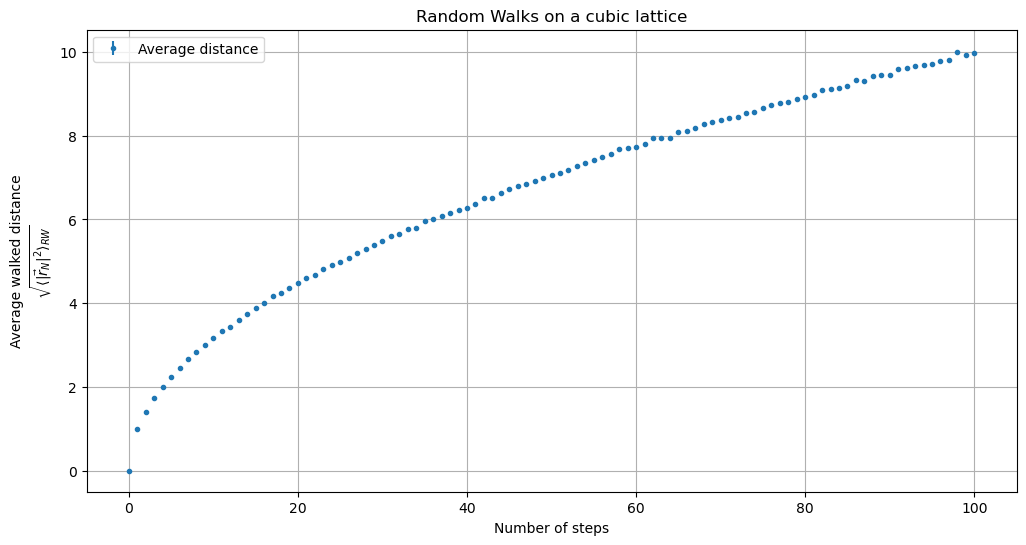

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
average_distance, error = np.loadtxt(
    "./EX2_Parallel_Random_Generator/output_files/ex2_2_discrete_random_walk.dat",
    usecols=(1,2), delimiter=",", skiprows=1, unpack=True
)

# X-axis = number of steps
x = np.arange(len(average_distance))

# Plot
plt.figure(figsize=(12,6))
plt.errorbar(
    x, average_distance, yerr=error, fmt='o', markersize=3, linestyle='', label='Average distance'
)
#plt.plot(x, average_distance, marker='o', linestyle='', markersize=2, label='Average distance')
plt.grid(True)
plt.xlabel("Number of steps")
plt.ylabel("Average walked distance\n" r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random Walks on a cubic lattice")
plt.legend()
plt.show()

### 2) Continuum

Sampling **uniformly** the solid angle: $\theta \in [0,\pi]$ and $\phi \in [0,2\pi]$. This ensures that each direction in a 3D space has an equal probability of being chosen.

To sample $\phi \in [0,2\pi]$ we simply "rescale" our uniformly distributed random variable $u$ by $2 \pi$.

Sampling $\theta \in [0,\pi]$ is a little bit more intricate. In fact, rescaling $u$ by $\pi$ wont translate into points uniformly distributed on a sphere because their position depend also on $sin(\theta)$.

$cos(\theta)$, however, is uniformly distributed between -1 and 1. Unsing $u\in [0,1]$ we have:

$$ cos(\theta) = 1 -2u $$

Then,

$$ u = arccos(1-2u) $$

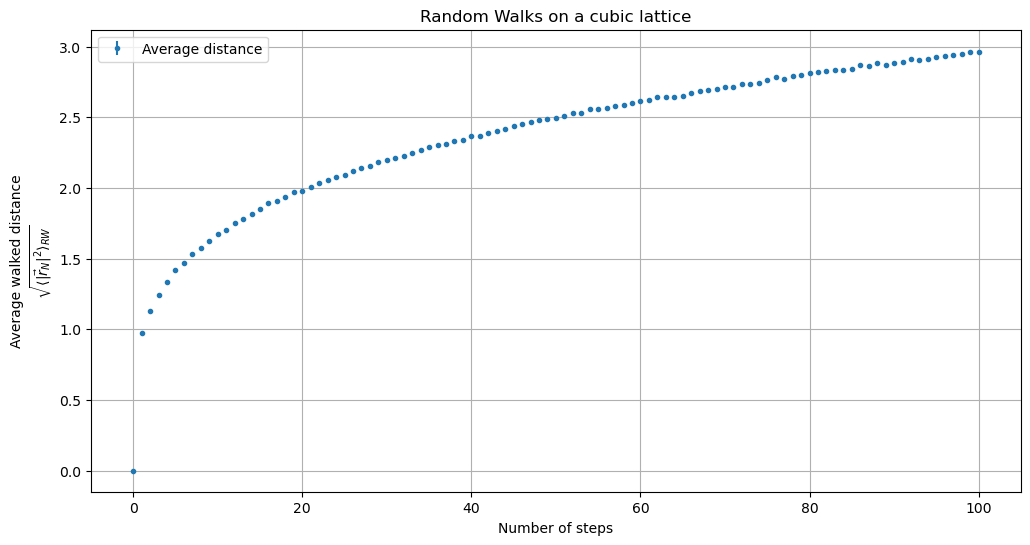

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
average_distance, error = np.loadtxt(
    "./EX2_Parallel_Random_Generator/output_files/ex2_2_continuous_random_walk.dat",
    usecols=(1,2), delimiter=",", skiprows=1, unpack=True
)

# X-axis = number of steps
x = np.arange(len(average_distance))

# Plot
plt.figure(figsize=(12,6))
plt.errorbar(
    x, average_distance, yerr=error, fmt='o', markersize=3, linestyle='', label='Average distance'
)
#plt.plot(x, average_distance, marker='o', linestyle='', markersize=2, label='Average distance')
plt.grid(True)
plt.xlabel("Number of steps")
plt.ylabel("Average walked distance\n" r"$\sqrt{\langle |\vec{r}_N|^2 \rangle_{RW}}$")
plt.title("Random Walks on a sphere")
plt.legend()
plt.show()